# Customer Behavior EDA (Legacy Monolith)

This notebook is retained for reference.

Split notebooks for active work:
- `02a_customer_kpi_segments.ipynb`
- `02b_customer_retention_clv.ipynb`
- `02c_customer_trends_diagnostics.ipynb`

In [13]:
import sys
from pathlib import Path
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

In [14]:
DATA_PATH = '../../data/processed/quality'

# === POLARS: Lazy load all tables from CSV ===
orders_pl               = pl.scan_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior_pl = pl.scan_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train_pl = pl.scan_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products_pl             = pl.scan_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles_pl               = pl.scan_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments_pl          = pl.scan_csv(Path(DATA_PATH) / 'departments_clean.csv')
order_dates_pl          = pl.scan_csv('../../data/processed/features/orders_with_dates.csv').with_columns(
    pl.col("order_date").str.to_date()
)

# === POLARS: Build full DataFrame with joins (lazy → collect) ===
df = (
    orders_pl
    .join(order_products_prior_pl, on="order_id", how="inner")
    .join(order_dates_pl.select(["order_id", "order_date"]), on="order_id", how="left")
    .join(products_pl.select(["product_id", "aisle_id", "department_id", "product_name"]), on="product_id", how="left")
    .join(aisles_pl.select(["aisle_id", "aisle"]), on="aisle_id", how="left")
    .join(departments_pl.select(["department_id", "department"]), on="department_id", how="left")
    .with_columns([
        pl.col("order_date").cast(pl.Date),
        pl.col("order_date").dt.month().alias("order_month"),
    ])
    .collect()
)

# Keep tables dict as Polars DataFrames
tables = {
    'orders':               orders_pl.collect(),
    'order_products_prior': order_products_prior_pl.collect(),
    'products':             products_pl.collect(),
    'aisles':               aisles_pl.collect(),
    'departments':          departments_pl.collect(),
}

print(f"Loaded {len(df):,} records with {df['user_id'].n_unique():,} unique customers")
print(f"Date range: {df['order_date'].min()} to {df['order_date'].max()}")
print(f"Columns: {df.columns}\n")
df.head(PREVIEW_ROWS)

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered', 'order_date', 'aisle_id', 'department_id', 'product_name', 'aisle', 'department', 'order_month']



order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,order_date,aisle_id,department_id,product_name,aisle,department,order_month
i64,i64,str,i64,i64,i64,f64,i64,i64,i64,date,i64,i64,str,str,str,i8
2,202279,"""prior""",3,5,9,8.0,33120,1,1,2015-01-29,86,16,"""Organic Egg Whites""","""eggs""","""dairy eggs""",1
2,202279,"""prior""",3,5,9,8.0,28985,2,1,2015-01-29,83,4,"""Michigan Organic Kale""","""fresh vegetables""","""produce""",1
2,202279,"""prior""",3,5,9,8.0,9327,3,0,2015-01-29,104,13,"""Garlic Powder""","""spices seasonings""","""pantry""",1
2,202279,"""prior""",3,5,9,8.0,45918,4,1,2015-01-29,19,13,"""Coconut Butter""","""oils vinegars""","""pantry""",1
2,202279,"""prior""",3,5,9,8.0,30035,5,0,2015-01-29,17,13,"""Natural Sweetener""","""baking ingredients""","""pantry""",1
2,202279,"""prior""",3,5,9,8.0,17794,6,1,2015-01-29,83,4,"""Carrots""","""fresh vegetables""","""produce""",1
2,202279,"""prior""",3,5,9,8.0,40141,7,1,2015-01-29,105,13,"""Original Unflavored Gelatine M…","""doughs gelatins bake mixes""","""pantry""",1
2,202279,"""prior""",3,5,9,8.0,1819,8,1,2015-01-29,88,13,"""All Natural No Stir Creamy Alm…","""spreads""","""pantry""",1
2,202279,"""prior""",3,5,9,8.0,43668,9,0,2015-01-29,123,4,"""Classic Blend Cole Slaw""","""packaged vegetables fruits""","""produce""",1


In [15]:
def show_df(df, title):
    """
    ฟังก์ชันสำหรับแสดงผล DataFrame พร้อมหัวข้อ Markdown
    """
    display(Markdown(f"#### {title}"))
    display(df)

## 1) Data Setup & KPI Baseline

**Data Mode Configuration**

ส่วนนี้ใช้ตั้งค่า environment และสร้าง baseline KPI ต่อผู้ใช้เพื่อดูภาพรวมก่อนลงลึก

In [16]:
# 1. Add cumulative reorder per customer using Polars window function
df = df.with_columns(
    pl.col("reordered").cum_sum().over("user_id").alias("cumulative_reorder_per_customer")
)

# 2. Customer KPI aggregation
customer_kpi = (
    df.group_by("user_id")
    .agg([
        pl.col("order_number").max().alias("total_orders"),
        pl.col("product_id").count().alias("total_lines"),
        pl.col("reordered").mean().alias("reorder_rate"),
        pl.col("days_since_prior_order").mean().alias("avg_days_between_orders"),
        pl.col("cumulative_reorder_per_customer").max().alias("cumulative_reorder_last"),
    ])
)

# 3. Display summaries
display(Markdown("### Customer KPI summary:"))
display(customer_kpi.drop("user_id").describe())

display(Markdown("### Customer KPI detailed summary:"))
display(customer_kpi.describe())

# 4. Summary by reordered
summary_by_reordered = (
    df.group_by("reordered")
    .agg([
        pl.col("days_since_prior_order").median().alias("median_days_since_prior"),
        pl.col("order_number").median().alias("median_order_number"),
        pl.col("cumulative_reorder_per_customer").median().alias("median_cumulative_reorder"),
        pl.col("order_id").count().alias("sample_size"),
    ])
    .sort("reordered")
)

display(Markdown("### Summary by reordered:"))
display(summary_by_reordered)

### Customer KPI summary:

statistic,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
str,f64,f64,f64,f64,f64
"""count""",206209.0,206209.0,206209.0,206209.0,206209.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",15.590367,157.289396,0.432249,13.013674,92.753158
"""std""",16.654774,204.208233,0.212144,5.661368,158.400413
"""min""",3.0,3.0,0.0,0.0,0.0
"""25%""",5.0,39.0,0.267857,8.475728,10.0
"""50%""",9.0,83.0,0.428571,12.672131,33.0
"""75%""",19.0,188.0,0.595745,17.186667,101.0
"""max""",99.0,3725.0,0.989529,29.70297,3275.0


### Customer KPI detailed summary:

statistic,user_id,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
str,f64,f64,f64,f64,f64,f64
"""count""",206209.0,206209.0,206209.0,206209.0,206209.0,206209.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",103105.0,15.590367,157.289396,0.432249,13.013674,92.753158
"""std""",59527.555167,16.654774,204.208233,0.212144,5.661368,158.400413
"""min""",1.0,3.0,3.0,0.0,0.0,0.0
"""25%""",51553.0,5.0,39.0,0.267857,8.475728,10.0
"""50%""",103105.0,9.0,83.0,0.428571,12.672131,33.0
"""75%""",154657.0,19.0,188.0,0.595745,17.186667,101.0
"""max""",206209.0,99.0,3725.0,0.989529,29.70297,3275.0


### Summary by reordered:

reordered,median_days_since_prior,median_order_number,median_cumulative_reorder,sample_size
i64,f64,f64,f64,u32
0,7.0,6.0,40.0,13307953
1,7.0,16.0,102.0,19126536


### Summary Customer KPI
- total_orders = ลูกค้าส่วนใหญ่สั่งประมาณ 9 ครั้งหรือน้อยกว่า 
- total_lines = รายการสินค้า (rows)” ที่ลูกค้าคนนั้นเคยซื้อทั้งหมด ค่าเฉลี่ยประมาณ 83 ชิ้น
- ลูกค้าซื้อเยอะต่อครั้ง (basket-style)
- Median reorder rate อยู่ที่ ~43% แสดงว่าลูกค้ากว่าครึ่งมีพฤติกรรมการซื้อซ้ำในระดับไม่สูงนัก ขณะที่มีลูกค้าบางกลุ่มที่มี reorder rate สูงมาก สะท้อนถึงการมีอยู่ของกลุ่มลูกค้าประจำ
- Median avg_days_between_orders = 12.67 , ครึ่งหนึ่งของลูกค้า ใช้เวลาน้อยกว่า ~12.67 วันในการกลับมาซื้ออีกครั้ง
- Median cumulative_reorder_last = 33 แปลว่า ลูกค้าทั่วไปใน dataset นี้ เคยซื้อของเดิมซ้ำมาแล้วประมาณ 30+ ครั้ง นี่ไม่ใช่ลูกค้าธรรมดาแล้วนะ → เป็น ลูกค้าประจำจริงจัง


### Insight from Customer KPI
แม้ median reorder rate จะอยู่ที่ ~43% ซึ่งสะท้อนว่าลูกค้าไม่ได้ซื้อซ้ำในทุกครั้ง แต่ median cumulative reorder อยู่ที่ 33 แสดงว่าลูกค้ามีการซื้อซ้ำสะสมในระยะยาวค่อนข้างสูง สะท้อนพฤติกรรมที่ผสมระหว่างการทดลองสินค้าใหม่และการซื้อสินค้าประจำ

## 2) Bivariate Behavior Comparison

ย้ายมารวมในโน้ตบุ๊กนี้เพื่อเปรียบเทียบพฤติกรรม reordered vs non-reordered ให้ต่อเนื่องจาก baseline.

### 2.1 Reorder Behavior

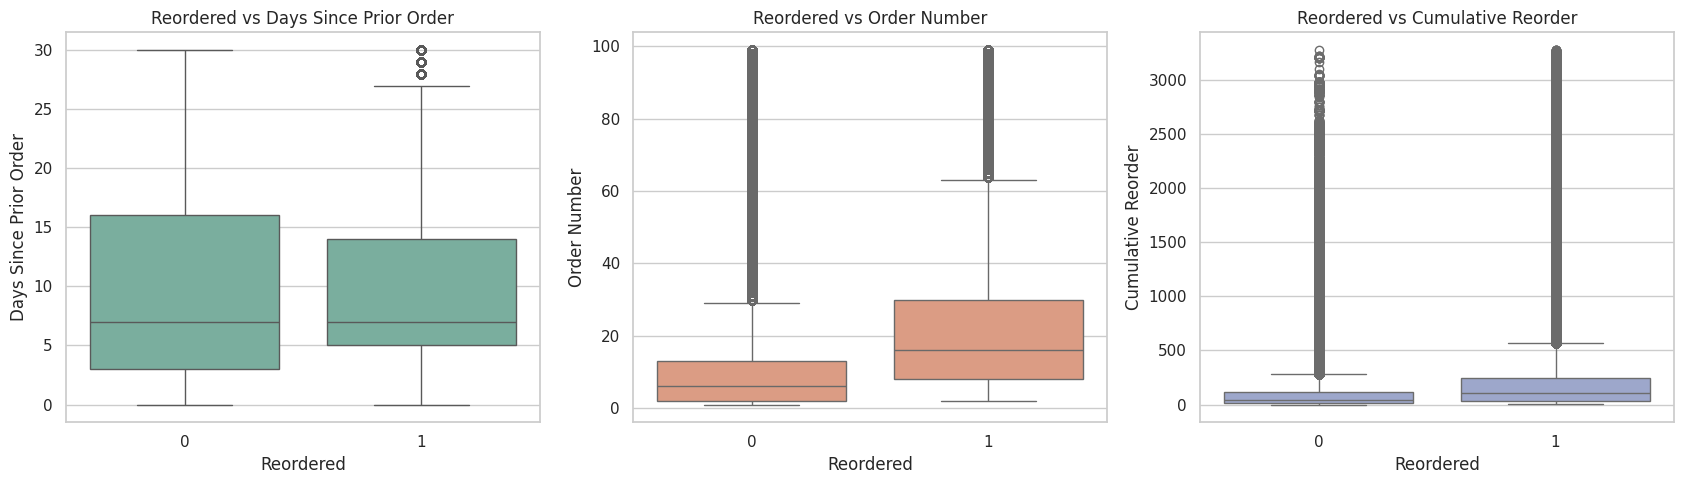

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Seaborn requires a pandas-compatible DataFrame — convert the needed columns only
_plot_df = df.select([
    "reordered", "days_since_prior_order", "order_number", "cumulative_reorder_per_customer"
]).to_pandas()

sns.boxplot(x="reordered", y="days_since_prior_order", data=_plot_df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=_plot_df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=_plot_df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [18]:
# Compare metrics between reordered and non-reordered items using Polars
_df_pl = df.select([
    "reordered", "days_since_prior_order", "order_number", "cumulative_reorder_per_customer"
])

_stats = (
    _df_pl
    .group_by("reordered")
    .agg([
        pl.col("days_since_prior_order").mean().alias("days_since_prior_order_mean"),
        pl.col("order_number").median().alias("order_number_median"),
        pl.col("cumulative_reorder_per_customer").median().alias("cumulative_reorder_median"),
    ])
    .sort("reordered")
)

# Compute differences (reordered=1 minus reordered=0) in Polars
diff_result = pl.DataFrame({
    "metric": ["days_since_prior_order", "order_number", "cumulative_reorder"],
    "difference": [
        _stats[1, "days_since_prior_order_mean"] - _stats[0, "days_since_prior_order_mean"],
        _stats[1, "order_number_median"]         - _stats[0, "order_number_median"],
        _stats[1, "cumulative_reorder_median"]   - _stats[0, "cumulative_reorder_median"],
    ],
}).sort("metric")

diff_result

metric,difference
str,f64
"""cumulative_reorder""",62.0
"""days_since_prior_order""",-0.44353
"""order_number""",10.0


มิติการวิเคราะห์,พฤติกรรมที่พบ (Behavior),Insight สำคัญ

⏱️ Timing,มักซื้อซ้ำทุก 7 วัน (ใกล้เคียงปกติ),เป็นเรื่องของ Habit ไม่ใช่แค่ความจำเป็น

🔢 Progression,ยิ่ง Order No. สูง ยิ่งมีโอกาส Reorder,Loyalty เพิ่มขึ้นตามจำนวนครั้งที่ซื้อ

🔁 Cumulative,กระุกตัวในกลุ่มที่มีประวัติ Reorder สูง,เป็นพฤติกรรมเฉพาะของ Power Users


🎯 Executive Summary
พฤติกรรมซื้อซ้ำขึ้นอยู่กับ Customer Maturity มากกว่าปัจจัยด้านเวลา:
    - Retention Loop: ลูกค้าใหม่โอกาสต่ำ ลูกค้าเก่าโอกาสสูง
    - Sticky Behavior: เมื่อเริ่ม Reorder แล้ว มักจะทำต่อไปเรื่อยๆ
    Key Takeaway: "Loyal users become increasingly loyal over time" — โฟกัสการรักษาฐานลูกค้าเก่าให้เหนียวแน่น เพราะยิ่งอยู่นาน ยิ่งมีมูลค่าสูงขึ้นแบบทวีคูณ

### 2.2 Order & Reorder Pattern by Day/Hour

In [21]:
# 1. Order-level aggregation
order_level = (
    df.group_by("order_id")
    .agg([
        pl.col("user_id").first(),
        pl.col("order_date").first(),
        pl.col("order_dow").first(),
        pl.col("order_hour_of_day").first(),
        pl.col("product_id").count().alias("total_products"),
        pl.col("reordered").mean().alias("reorder_rate"),
        pl.col("days_since_prior_order").max(),
    ])
)

# 2. Date-related columns & Weekday labels
day_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}

order_level = order_level.with_columns([
    pl.col("order_date").cast(pl.Date),
    pl.col("order_date").dt.month().alias("month_num"),
    pl.col("order_date").dt.strftime("%b").alias("month_name"),
    pl.col("order_date").dt.week().alias("week_of_year"),
    # Cast to String first so replace can swap int keys → string values safely
    pl.col("order_dow").cast(pl.String).replace(
        old=[str(k) for k in day_map.keys()],
        new=list(day_map.values()),
        return_dtype=pl.String,
    ).alias("day_name"),
])

# 3. Numeric summary
cols_to_sum = ["order_hour_of_day", "total_products", "reorder_rate", "days_since_prior_order", "month_num", "week_of_year"]

numeric_summary = order_level.select(cols_to_sum).describe()

# Cast value columns to Float64 (describe may return String in newer Polars)
float_cols = [c for c in numeric_summary.columns if c != "statistic"]
numeric_summary = (
    numeric_summary
    .with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in float_cols])
    .with_columns([
        pl.when(pl.col("statistic") != "count")
          .then(pl.col("reorder_rate") * 100)
          .otherwise(pl.col("reorder_rate"))
          .alias("reorder_rate")
    ])
    .with_columns([pl.col(c).round(2) for c in float_cols])
)

print("\nOrder-level numeric summary (reorder_rate in %):")
print(numeric_summary)

# 4. Quality checks
print("\nQuality checks:")
print(f"Unique orders: {order_level['order_id'].n_unique():,}")
print(f"Date range: {order_level['order_date'].min()} to {order_level['order_date'].max()}")
print(f"Unique months: {order_level['month_name'].n_unique()}")

/tmp/ipykernel_411222/3744724056.py:24: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("order_dow").cast(pl.String).replace(



Order-level numeric summary (reorder_rate in %):
shape: (9, 7)
┌────────────┬──────────────┬──────────────┬──────────────┬─────────────┬────────────┬─────────────┐
│ statistic  ┆ order_hour_o ┆ total_produc ┆ reorder_rate ┆ days_since_ ┆ month_num  ┆ week_of_yea │
│ ---        ┆ f_day        ┆ ts           ┆ ---          ┆ prior_order ┆ ---        ┆ r           │
│ str        ┆ ---          ┆ ---          ┆ f64          ┆ ---         ┆ f64        ┆ ---         │
│            ┆ f64          ┆ f64          ┆              ┆ f64         ┆            ┆ f64         │
╞════════════╪══════════════╪══════════════╪══════════════╪═════════════╪════════════╪═════════════╡
│ count      ┆ 3.214874e6   ┆ 3.214874e6   ┆ 3.214874e6   ┆ 3.214874e6  ┆ 3.214874e6 ┆ 3.214874e6  │
│ null_count ┆ 0.0          ┆ 0.0          ┆ 0.0          ┆ 0.0         ┆ 0.0        ┆ 0.0         │
│ mean       ┆ 13.44        ┆ 10.09        ┆ 59.87        ┆ 10.02       ┆ 5.66       ┆ 22.69       │
│ std        ┆ 4.23        

Column,Median (50%),Max,"Interpretation (The ""Peak"" Logic)"
order_hour_of_day,13.00,23.00,Peak: น่าจะอยู่ช่วง 10:00-16:00 (Q1-Q3) โดยมีค่ากลางที่บ่ายโมง
total_products,8.00,145.00,"Max is Outlier: คนส่วนใหญ่ซื้อ 8 ชิ้น แต่มี ""วาฬ"" สั่งทีเดียว 145 ชิ้น"
reorder_rate,66.67,100.00,High Loyalty: ค่ากลางสูงมาก สะท้อนว่าสินค้าเกินครึ่งตะกร้าคือของเดิม
days_since_prior_order,7.00,30.00,"Weekly Cycle: ลูกค้า ""ส่วนใหญ่"" กลับมาทุกอาทิตย์ (7 วัน)"

"ข้อมูลแสดงให้เห็นพฤติกรรมแบบ Right-Skewed Distribution ในจำนวนสินค้าต่อออเดอร์ โดยมีค่ากลางอยู่ที่ 8 ชิ้น แม้จะมีค่าสูงสุดถึง 145 ชิ้น ก็ตาม ส่วนช่วงเวลา Peak ของการสั่งซื้อจะเกาะกลุ่มหนาแน่นในช่วงกลางวัน (10:00 - 16:00 น.) ซึ่งสอดคล้องกับรอบการสั่งซื้อซ้ำทุก 7 วัน"

#### 2.2.1 Day-Hour KPI Grid (median-focused view)

In [22]:
_DAY_ORDER = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

# Build a complete 7×24 reference grid so empty slots are explicit
all_day_hour = pl.DataFrame({
    "day_name": [d for d in _DAY_ORDER for _ in range(24)],
    "order_hour_of_day": [h for _ in _DAY_ORDER for h in range(24)],
})

# Aggregate KPIs per day × hour slot
_agg = (
    order_level.group_by(["day_name", "order_hour_of_day"])
    .agg([
        pl.col("order_id").n_unique().alias("order_count"),
        pl.col("total_products").mean().alias("avg_products_per_order"),
        pl.col("total_products").median().alias("median_products_per_order"),
        pl.col("reorder_rate").mean().alias("avg_reorder_rate"),
        pl.col("reorder_rate").median().alias("median_reorder_rate"),
        pl.col("days_since_prior_order").mean().alias("avg_days_between_orders"),
        pl.col("days_since_prior_order").median().alias("median_days_between_orders"),
    ])
)

# Left join so every slot in the grid is preserved
customer_kpi = (
    all_day_hour
    .join(_agg, on=["day_name", "order_hour_of_day"], how="left")
    .with_columns(pl.col("order_count").fill_null(0))
    .sort(["day_name", "order_hour_of_day"])
)

# Robust feature view for modeling: prefer median-based metrics
customer_kpi_model = customer_kpi.select([
    "day_name",
    "order_hour_of_day",
    "order_count",
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
])

# Add model-friendly helper features
_day_code_map = {d: i for i, d in enumerate(_DAY_ORDER)}
customer_kpi_model = customer_kpi_model.with_columns([
    pl.col("order_count").eq(0).cast(pl.Int8).alias("is_empty_slot"),
    pl.col("day_name").replace(
        old=list(_day_code_map.keys()),
        new=list(_day_code_map.values()),
        return_dtype=pl.Int8,
    ).alias("day_name_code"),
])

# Impute missing median-based features with global medians
model_feature_cols = [
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]
missing_before = customer_kpi_model.select(model_feature_cols).null_count()

for col in model_feature_cols:
    fill_value = customer_kpi_model[col].drop_nulls().median()
    if fill_value is None:
        fill_value = 0.0
    customer_kpi_model = customer_kpi_model.with_columns(
        pl.col(col).fill_null(fill_value)
    )

missing_after = customer_kpi_model.select(model_feature_cols).null_count()

display(Markdown("### Rows per day check (should be 24 each):"))
display(
    customer_kpi
    .group_by("day_name")
    .agg(pl.col("order_hour_of_day").count().alias("rows_per_day"))
    .sort("day_name")
)

display(Markdown("### Median-based view (recommended for robust analysis/modeling):"))
display(customer_kpi_model.group_by("day_name").head(1))

if SHOW_VERBOSE_TABLES:
    show_df(missing_before, title="Model feature missing values (before imputation):")
    show_df(missing_after, title="Model feature missing values (after imputation):")

expected_slots = 7 * 24
actual_slots = len(customer_kpi)
total_orders_from_grid = customer_kpi["order_count"].sum()
total_orders_raw = order_level["order_id"].n_unique()

print(f"Slots check: expected={expected_slots}, actual={actual_slots}")
print(f"Order coverage check: grid_sum={total_orders_from_grid:,}, raw_unique_orders={total_orders_raw:,}")

/tmp/ipykernel_411222/2924767993.py:45: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("day_name").replace(


### Rows per day check (should be 24 each):

day_name,rows_per_day
str,u32
"""Fri""",24
"""Mon""",24
"""Sat""",24
"""Sun""",24
"""Thu""",24
"""Tue""",24
"""Wed""",24


### Median-based view (recommended for robust analysis/modeling):

day_name,order_hour_of_day,order_count,median_products_per_order,median_reorder_rate,median_days_between_orders,is_empty_slot,day_name_code
str,i64,u32,f64,f64,f64,i8,i8
"""Fri""",0,2989,8.0,0.615385,7.0,0,5
"""Mon""",0,3475,9.0,0.666667,8.0,0,1
"""Sat""",0,3067,8.0,0.636364,7.0,0,6
"""Sun""",0,3692,9.0,0.642857,8.0,0,0
"""Thu""",0,2476,8.0,0.625,8.0,0,4
"""Tue""",0,2906,8.0,0.636364,8.0,0,2
"""Wed""",0,2767,8.0,0.625,8.0,0,3


Slots check: expected=168, actual=168
Order coverage check: grid_sum=3,214,874, raw_unique_orders=3,214,874


### TOP 10 Days have High Peak OrderCount

In [23]:
customer_kpi.sort("order_count", descending=True).head(10)

day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
str,i64,u32,f64,f64,f64,f64,f64,f64
"""Mon""",10,52999,10.382196,8.0,0.63502,0.705882,10.113361,7.0
"""Sun""",14,50484,11.189605,10.0,0.583625,0.633333,10.760875,7.0
"""Sun""",15,50020,11.036905,9.0,0.587241,0.636364,10.765274,7.0
"""Sun""",13,49997,11.16895,10.0,0.585307,0.636364,10.780067,7.0
"""Mon""",9,49533,10.218339,8.0,0.659765,0.75,9.775039,7.0
"""Mon""",11,49008,10.399771,8.0,0.615111,0.666667,10.234431,7.0
"""Sun""",12,47729,11.215047,10.0,0.583374,0.625,10.75715,7.0
"""Sun""",11,47357,11.312646,10.0,0.585106,0.636364,10.772895,7.0
"""Sun""",16,45930,10.921141,9.0,0.585181,0.631579,10.699216,7.0


### TOP Hour Days have High Peak OrderCount

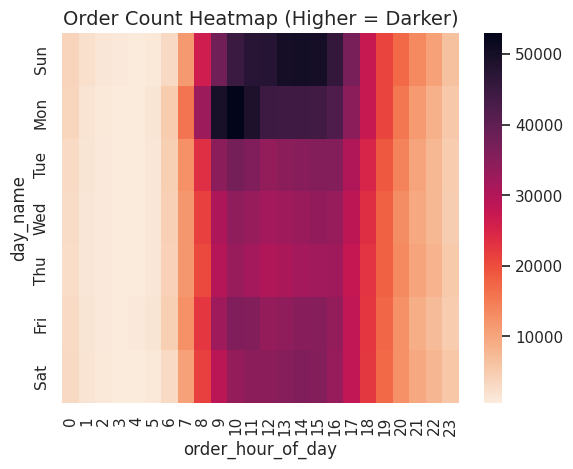

In [24]:
pivot = (
    customer_kpi
    .to_pandas()
    .pivot(index="day_name", columns="order_hour_of_day", values="order_count")
    .reindex(_DAY_ORDER)
)

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Order Count Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [25]:
order_count_pivot_per_day = (
    customer_kpi
    .to_pandas()
    .pivot(index="day_name", columns="order_hour_of_day", values="order_count")
    .reindex(_DAY_ORDER)
)

print(order_count_pivot_per_day)

order_hour_of_day    0     1     2    3    4     5     6      7      8   \
day_name                                                                  
Sun                3692  2235  1299  888  750  1076  3138  11530  26223   
Mon                3475  1735  1063  711  761  1523  5101  15792  32563   
Tue                2906  1485   892  679  700  1330  4524  12550  23488   
Wed                2767  1407   889  605  666  1265  4314  11739  21305   
Thu                2476  1414   837  640  694  1251  4135  11823  20597   
Fri                2989  1539   953  796  857  1466  4573  12590  22623   
Sat                3067  1781  1137  801  747  1061  3007  10632  21522   

order_hour_of_day     9   ...     14     15     16     17     18     19  \
day_name                  ...                                             
Sun                37990  ...  50484  50020  45930  36874  27347  20972   
Mon                49533  ...  44220  43913  42200  34610  27293  20926   
Tue                34499

### 📊 สรุปพฤติกรรมการสั่งซื้อจาก (Order Count)

1. **ช่วงเวลาที่มีคำสั่งซื้อสูงสุด (Peak Hours)**
   - ประมาณ **8:00 – 17:00**, โดยเฉพาะ **10:00 – 16:00**
   - ลูกค้าส่วนใหญ่สั่งซื้อในช่วงกลางวัน

2. **แนวโน้มตามวันของสัปดาห์**
   - **วันจันทร์ (Mon)** มียอดสูงสุด
   - วันพฤหัส–ศุกร์ สูงรองลงมา
   - วันเสาร์–อาทิตย์ ยอดน้อยกว่า แต่ยังมี peak กลางวัน

3. **ช่วงเวลาที่คำสั่งซื้อน้อยสุด**
   - **0:00 – 6:00** เป็นช่วงที่แทบไม่มีคำสั่งซื้อ

4. **แนวโน้มทั่วไป**
   - รูปแบบคล้าย **ระฆังกลางวัน** (bell-shaped)
   - Peak ของแต่ละวันอยู่กลางวัน ± shift เล็กน้อย

💡 **ข้อเสนอแนะเชิงธุรกิจ**
- ส่งโปรโมชันหรือแจ้งเตือน → ช่วง 10:00 – 16:00
- วางแผนพนักงาน / logistic → เพิ่มกำลังช่วงกลางวัน ลดช่วงกลางคืน
- โมเดล forecast → ใช้ feature `day_name` + `order_hour_of_day` กับ median order_count

### TOP 10 Days have average ReorderRate

In [26]:
customer_kpi.sort("median_reorder_rate", descending=True).head(10)

day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
str,i64,u32,f64,f64,f64,f64,f64,f64
"""Mon""",6,5101,10.346599,8.0,0.661395,0.75,9.819251,7.0
"""Mon""",7,15792,10.476317,9.0,0.675925,0.75,9.816553,7.0
"""Mon""",8,32563,10.23668,8.0,0.669218,0.75,9.737125,7.0
"""Mon""",9,49533,10.218339,8.0,0.659765,0.75,9.775039,7.0
"""Tue""",6,4524,9.685234,8.0,0.648325,0.737986,10.044651,7.0
"""Tue""",7,12550,9.759363,8.0,0.651235,0.727273,9.860398,7.0
"""Wed""",7,11739,9.430446,8.0,0.64711,0.727273,9.574495,7.0
"""Mon""",5,1523,9.469468,7.0,0.639792,0.714286,10.694682,7.0
"""Sat""",7,10632,11.055493,9.0,0.637936,0.714286,9.900113,7.0


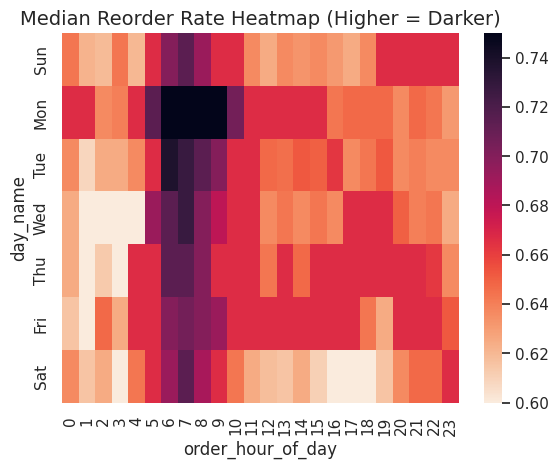

In [27]:
pivot = (
    customer_kpi
    .to_pandas()
    .pivot(index="day_name", columns="order_hour_of_day", values="median_reorder_rate")
    .reindex(_DAY_ORDER)
)

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Median Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [28]:
reorder_rate_pivot_per_day = (
    customer_kpi
    .to_pandas()
    .pivot(index="day_name", columns="order_hour_of_day", values="median_reorder_rate")
    .reindex(_DAY_ORDER)
)

print(reorder_rate_pivot_per_day)

order_hour_of_day        0         1         2         3         4         5   \
day_name                                                                        
Sun                0.642857  0.622222  0.619048  0.642857  0.620192  0.666667   
Mon                0.666667  0.666667  0.636364  0.640000  0.666667  0.714286   
Tue                0.636364  0.608696  0.625000  0.625000  0.636364  0.666667   
Wed                0.625000  0.600000  0.600000  0.600000  0.600000  0.692308   
Thu                0.625000  0.600000  0.612903  0.600000  0.666667  0.666667   
Fri                0.615385  0.600000  0.647059  0.625000  0.666667  0.666667   
Sat                0.636364  0.615385  0.625000  0.600000  0.642857  0.666667   

order_hour_of_day        6         7         8         9   ...        14  \
day_name                                                   ...             
Sun                0.700000  0.714286  0.692308  0.666667  ...  0.633333   
Mon                0.750000  0.750000  0.7

<Axes: xlabel='order_hour_of_day', ylabel='median_reorder_rate'>

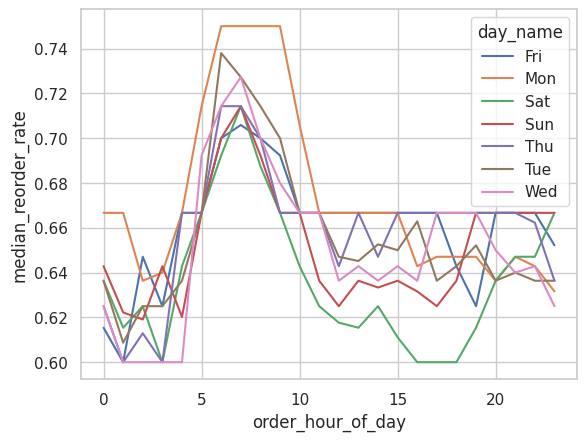

In [29]:
sns.lineplot(
    data=customer_kpi.to_pandas(),
    x="order_hour_of_day",
    y="median_reorder_rate",
    hue="day_name",
)

### 📊 Median Reorder Rate by Hour & Day — Key Insights

### 🔥 1. Early Morning Peak (06:00–08:00)
- ช่วงเวลา **06:00–08:00 น.** มีค่า reorder rate สูงที่สุด (~0.74–0.75)
- เห็นได้ชัดในหลายวัน โดยเฉพาะ **วันจันทร์ (Monday)**
- แสดงถึงพฤติกรรม **routine purchasing / restocking**

> 📌 Insight: ผู้ใช้ช่วงเช้ามีแนวโน้มเป็นลูกค้าประจำ (high loyalty)

---

### 📅 2. Monday Shows Strongest Reorder Behavior
- วันจันทร์มี peak สูงสุดของทั้ง dataset
- ค่า reorder สูงต่อเนื่องในช่วงเช้า

> 📌 Insight: เป็นพฤติกรรม “start-of-week restocking”

---

### 📉 3. Midday Drop (10:00–17:00)
- ช่วงสายถึงบ่าย ค่า reorder ลดลง (~0.60–0.66)
- พบ pattern นี้แทบทุกวัน

> 📌 Insight: ลูกค้ามีแนวโน้ม “explore สินค้าใหม่” มากกว่าซื้อซ้ำ

---

### 🌙 4. Evening Recovery (18:00–23:00)
- ค่า reorder กลับมาอยู่ระดับปานกลาง (~0.63–0.67)
- ไม่สูงเท่าช่วงเช้า แต่ไม่ต่ำสุด

> 📌 Insight: มีการซื้อซ้ำบ้าง แต่ไม่ใช่ช่วง peak ของ loyalty

---

### 📊 5. Clear Behavioral Pattern (Not Flat)
- ค่า reorder rate ไม่ได้คงที่ทั้งวัน
- มีความแตกต่างชัดเจนระหว่าง:
  - ช่วง peak (~0.75)
  - ช่วงต่ำ (~0.60)

> 📌 Insight: Time-of-day มีผลต่อพฤติกรรมลูกค้าอย่างมีนัยสำคัญ

---

### 📆 6. Weekday vs Weekend Behavior
- วันธรรมดา (Mon–Fri): มี pattern ชัดเจน โดยเฉพาะช่วงเช้า
- วันหยุด (Sat–Sun): ค่า reorder ต่ำกว่าเล็กน้อย และกระจายมากกว่า

> 📌 Insight: Weekend มีแนวโน้มเป็น exploratory behavior มากขึ้น

---

### 🧠 Overall Conclusion
- **Morning users = High loyalty (reorder สูง)**
- **Midday users = Exploration mode**
- **Monday = Key restocking day**
- พฤติกรรมลูกค้าเปลี่ยนตามช่วงเวลาอย่างชัดเจน

---

### 🎯 Business Implications
- 📌 Promote "reorder / subscription" → ช่วงเช้า
- 📌 Promote "new products / discovery" → ช่วงบ่าย
- 📌 Target campaigns → วันจันทร์ (high intent users)

<Axes: xlabel='day_name', ylabel='reorder_rate'>

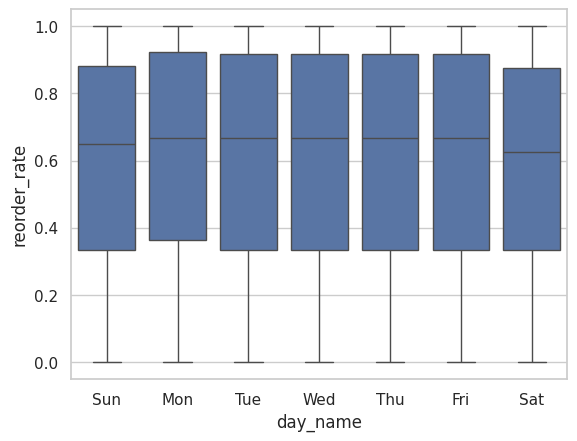

In [30]:
sns.boxplot(
    data=order_level.to_pandas(),
    x="day_name",
    y="reorder_rate",
    order=_DAY_ORDER,
)

## 5) Basket Value & Repeat Rate by Category

In [31]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5,
}

# 2) CREATE VALUE INDEX via join-based lookup (no map_elements overhead)
_weight_df = pl.DataFrame({
    "aisle": list(value_weight_map.keys()),
    "value_weight": list(value_weight_map.values()),
})

df = (
    df.join(_weight_df, on="aisle", how="left")
    .with_columns([
        pl.col("value_weight").fill_null(1.5),
        pl.lit(1).cast(pl.Int8).alias("quantity"),
    ])
    .with_columns(
        (pl.col("quantity").cast(pl.Float64) * pl.col("value_weight")).alias("value_index")
    )
)

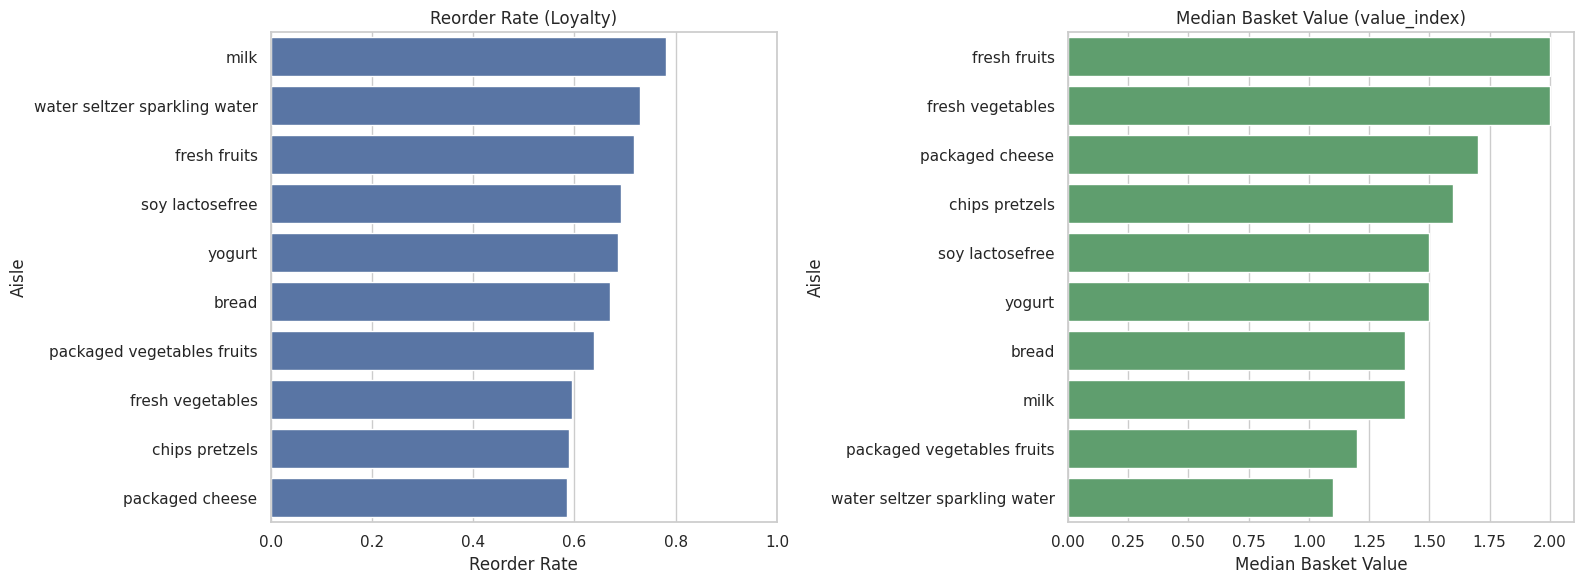

aisle,order_lines,reorder_rate,median_basket_value
str,u32,f64,f64
"""fresh fruits""",3642188,0.718104,2.0
"""fresh vegetables""",3418021,0.594546,2.0
"""packaged vegetables fruits""",1765313,0.638514,1.2
"""yogurt""",1452343,0.686489,1.5
"""packaged cheese""",979763,0.585226,1.7
"""milk""",891015,0.781428,1.4
"""water seltzer sparkling water""",841533,0.729593,1.1
"""chips pretzels""",722470,0.588795,1.6
"""soy lactosefree""",638253,0.692551,1.5


In [32]:
# 1. Config & Data Prep
CATEGORY_COL = ["aisle"]
TOP_N = 10

group_col = CATEGORY_COL[0]
category_df = df  # Polars DataFrame — no .copy() needed (Polars is immutable)

# Add group_col via join if missing
if group_col not in category_df.columns:
    category_df = category_df.join(
        tables["products"].select(["product_id", group_col]).unique(subset=["product_id"]),
        on="product_id",
        how="left",
    )

# Fill nulls to avoid silent groupby gaps
category_df = category_df.with_columns(
    pl.col(group_col).fill_null("Unknown")
)

# Use actual price if available, otherwise fall back to value_index
value_col = "total_price" if "total_price" in category_df.columns else "value_index"
if value_col not in category_df.columns:
    raise ValueError("Need `total_price` or `value_index` in df before running this cell.")

# 2. Line-level metrics (reorder rate per category)
line_metrics = (
    category_df.group_by(group_col)
    .agg([
        pl.col("product_id").count().alias("order_lines"),
        pl.col("reordered").mean().alias("reorder_rate"),
    ])
)

# 3. Basket-level metrics (median basket value per category)
basket_metrics = (
    category_df.group_by(["order_id", group_col])
    .agg(pl.col(value_col).sum().alias("basket_val"))
    .group_by(group_col)
    .agg(pl.col("basket_val").median().alias("median_basket_value"))
)

# 4. Combine and keep top N by volume
category_summary = (
    line_metrics.join(basket_metrics, on=group_col, how="left")
    .sort("order_lines", descending=True)
    .head(TOP_N)
)

# --- Visualization (seaborn requires pandas) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_pd = category_summary.to_pandas()

# Chart 1: Reorder Rate (Loyalty)
sns.barplot(
    data=cat_pd.sort_values("reorder_rate", ascending=False),
    x="reorder_rate",
    y=group_col,
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("Reorder Rate (Loyalty)")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Reorder Rate")
axes[0].set_ylabel(group_col.title())

# Chart 2: Median Basket Value (Monetary)
sns.barplot(
    data=cat_pd.sort_values("median_basket_value", ascending=False),
    x="median_basket_value",
    y=group_col,
    ax=axes[1],
    color="#55A868",
)
axes[1].set_title(f"Median Basket Value ({value_col})")
axes[1].set_xlabel("Median Basket Value")
axes[1].set_ylabel(group_col.title())

plt.tight_layout()
plt.show()

category_summary